In [1]:
!pip install yfinance statsmodels seaborn -q
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [2]:
startll ="2019-01-01"
endll ="2025-12-31"

In [3]:
tickers ={
    "MOEX": "IMOEX.ME",  "RTS": "RTSI.ME",  "SP500": "^GSPC",  "NASDAQ": "^IXIC",  "DOW": "^DJI",   "DAX": "^GDAXI",  "FTSE": "^FTSE", "CAC40": "^FCHI",  "NIKKEI": "^N225", "HANGSENG": "^HSI", "SHANGHAI": "000001.SS",   "SP400": "^MID",   "SP600": "^SML",   "EUROSTOXX": "^STOXX50E",   "IBEX": "^IBEX",  "TSX": "^GSPTSE",  "KOSPI": "^KS11", "BOVESPA": "^BVSP",  "SENSEX": "^BSESN",   "ASX200": "^AXJO"}
panellist =[]
for name,ticker in tickers.items():
    df =yf.download(ticker, start=startll, end=endll, auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns= df.columns.get_level_values(0)
    df =df[["Close", "Volume"]].copy()
    df["returns"] =np.log(df["Close"]/df["Close"].shift(1))
    df["volatility_21d"] =df["returns"].rolling(21).std()
    df["market"] =  name
    df=df.reset_index()
    panellist.append(df)
paneldata = pd.concat(panellist, axis=0, ignore_index=True)
paneldata = paneldata.dropna(subset=["returns"])
paneldata = paneldata.sort_values(["market", "Date"])
cols = paneldata.columns.tolist()
cols.remove("market")
dateiindex = cols.index("Date")
cols.insert(dateiindex + 1, "market")
paneldata = paneldata[cols]

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['RTSI.ME']: YFPricesMissingError('possibly delisted; no price data found  (1d 2019-01-01 -> 2025-12-31)')
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
ERROR:yfinance:

In [4]:
vix = yf.download("^VIX", start=startll, end=endll, auto_adjust=True)[["Close"]]
vix.columns = ["VIX"]
vix = vix.reset_index()
brent = yf.download("BZ=F", start=startll, end=endll, auto_adjust=True)[["Close"]]
brent.columns = ["Brent"]
brent = brent.reset_index()
dxy = yf.download("DX-Y.NYB", start=startll, end=endll, auto_adjust=True)[["Close"]]
dxy.columns = ["DXY"]
dxy = dxy.reset_index()
us10y = yf.download("^TNX", start=startll, end=endll, auto_adjust=True)[["Close"]]
us10y.columns = ["US10Y"]
us10y = us10y.reset_index()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [5]:
!wget -q https://raw.githubusercontent.com/OxCGRT/covid-policy-tracker/master/data/OxCGRT_nat_latest.csv
covid= pd.read_csv("OxCGRT_nat_latest.csv")
covid =covid[covid["CountryName"] == "Russia"]
covid["Date"]= pd.to_datetime(covid["Date"], format="%Y%m%d")
covid= covid[["Date", "StringencyIndex_Average"]]
covid.rename(columns={"StringencyIndex_Average": "COVID_Stringency"}, inplace=True)

In [6]:
paneldata= paneldata.merge(vix, on="Date",how="left")
paneldata= paneldata.merge(brent, on="Date", how="left")
paneldata= paneldata.merge(dxy, on="Date",how="left")
paneldata= paneldata.merge(us10y, on="Date",how="left")
paneldata= paneldata.merge(covid, on="Date",how="left")
paneldata[["VIX","Brent","DXY","US10Y","COVID_Stringency"]]= \
paneldata[["VIX","Brent","DXY","US10Y","COVID_Stringency"]].ffill()

In [7]:
paneldata =   paneldata[paneldata["Date"] >="2020-01-01"].copy()
print("final:")
print(paneldata["Date"].min(), "to",paneldata["Date"].max())
print("mis values")
print(paneldata.isnull().sum())
print("fin dataset")
print(paneldata.shape)

final:
2020-01-02 00:00:00 to 2025-12-30 00:00:00
mis values
Date                0
market              0
Close               0
Volume              0
returns             0
volatility_21d      0
VIX                 0
Brent               0
DXY                 0
US10Y               0
COVID_Stringency    0
dtype: int64
fin dataset
(26616, 11)


In [8]:
panelgrouped=paneldata.groupby("market")["returns"].describe()
display(panelgrouped)

,count,mean,std,min,25%,50%,75%,max
market,,,,,,,,
ASX200,1518.0,0.000175,0.010585,-0.102030,-0.004322,0.000837,0.005369,0.067665
BOVESPA,1494.0,0.000220,0.015496,-0.159930,-0.006769,0.000386,0.007811,0.130223
CAC40,1537.0,0.000203,0.012500,-0.130983,-0.005147,0.000769,0.006489,0.080561
DAX,1528.0,0.000402,0.012789,-0.130549,-0.004958,0.000756,0.006908,0.104143
DOW,1507.0,0.000350,0.012749,-0.138418,-0.004728,0.000743,0.006024,0.107643
EUROSTOXX,1510.0,0.000289,0.012905,-0.132405,-0.005321,0.000794,0.006693,0.088343
FTSE,1513.0,0.000182,0.010530,-0.115117,-0.003943,0.000663,0.005071,0.086664
HANGSENG,1475.0,-0.000059,0.015760,-0.141833,-0.009001,-0.000063,0.008402,0.086928
IBEX,1535.0,0.000389,0.012722,-0.151512,-0.005443,0.000885,0.007005,0.082253


In [9]:
print(paneldata.shape)
print(len(paneldata))
paneldata.info()
display(paneldata.describe())
display(paneldata.isnull().sum())

paneldata = paneldata.drop_duplicates()

(26616, 11)
26616
<class 'pandas.core.frame.DataFrame'>
Index: 26616 entries, 251 to 31085
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              26616 non-null  datetime64[ns]
 1   market            26616 non-null  object        
 2   Close             26616 non-null  float64       
 3   Volume            26616 non-null  float64       
 4   returns           26616 non-null  float64       
 5   volatility_21d    26616 non-null  float64       
 6   VIX               26616 non-null  float64       
 7   Brent             26616 non-null  float64       
 8   DXY               26616 non-null  float64       
 9   US10Y             26616 non-null  float64       
 10  COVID_Stringency  26616 non-null  float64       
dtypes: datetime64[ns](1), float64(9), object(1)
memory usage: 2.4+ MB


,Date,Close,Volume,returns,volatility_21d,VIX,Brent,DXY,US10Y,COVID_Stringency
count,26616,26616.000000,2.661600e+04,26616.000000,26616.000000,26616.000000,26616.000000,26616.000000,26616.000000,26616.000000
mean,2022-12-18 22:48:02.596934144,20894.393872,8.288294e+08,0.000321,0.011268,20.990245,73.881917,100.098279,2.935415,26.380478
min,2020-01-02 00:00:00,1218.550049,0.000000e+00,-0.404674,0.002268,11.860000,19.330000,89.440002,0.499000,0.000000
25%,2021-06-24 00:00:00,4100.462524,5.704000e+05,-0.005386,0.007244,15.890000,64.959999,96.029999,1.529000,11.110000
50%,2022-12-13 00:00:00,8558.800293,6.550000e+07,0.000762,0.009569,19.080000,75.290001,100.555000,3.549000,11.110000
75%,2024-06-07 00:00:00,24070.524414,3.937800e+08,0.006764,0.012880,24.150000,84.629997,104.230003,4.198000,42.130000
max,2025-12-30 00:00:00,164456.000000,1.630873e+10,0.182619,0.106094,82.690002,127.980003,114.110001,4.988000,87.040000
std,NaN,28497.027136,1.742922e+09,0.013471,0.007402,7.907412,18.846697,5.499468,1.409809,19.853345


,0
Date,0
market,0
Close,0
Volume,0
returns,0
volatility_21d,0
VIX,0
Brent,0
DXY,0
US10Y,0


In [10]:
moexdata = paneldata[paneldata["market"]=="MOEX"].copy()
moexdata = moexdata.dropna()
print("MOEX", moexdata.shape)

MOEX (1102, 11)


In [11]:
moexdata = moexdata.drop(columns=['Volume'])

In [39]:

print("moexdata.info()")
moexdata.info()
print("null check")
print(moexdata.isna().sum())
print(f"total observations: {len(moexdata)}")
print(f"date range: {moexdata['Date'].min().date()} to {moexdata['Date'].max().date()}")

moexdata.info()
<class 'pandas.core.frame.DataFrame'>
Index: 1100 entries, 17836 to 18935
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              1100 non-null   datetime64[ns]
 1   market            1100 non-null   object        
 2   Close             1100 non-null   float64       
 3   returns           1100 non-null   float64       
 4   volatility_21d    1100 non-null   float64       
 5   VIX               1100 non-null   float64       
 6   Brent             1100 non-null   float64       
 7   DXY               1100 non-null   float64       
 8   US10Y             1100 non-null   float64       
 9   COVID_Stringency  1100 non-null   float64       
 10  d_Brent           1100 non-null   float64       
 11  d_DXY             1100 non-null   float64       
 12  d_VIX             1100 non-null   float64       
 13  d_US10Y           1100 non-null   float64       
 14  d_COVID 

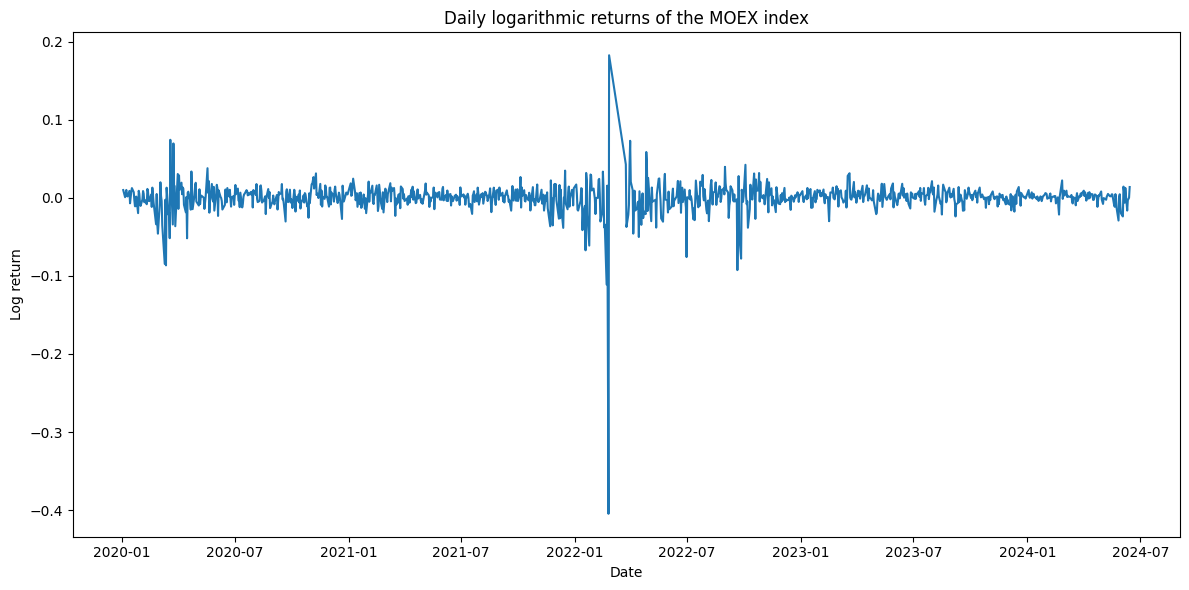

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(moexdata["Date"], moexdata["returns"])
plt.title("Daily logarithmic returns of the MOEX index")
plt.xlabel("Date")
plt.ylabel("Log return")
plt.tight_layout()
plt.savefig("returns.png", dpi=300, bbox_inches="tight")
plt.show()
##from google.colab import files
##files.download("returns.png")

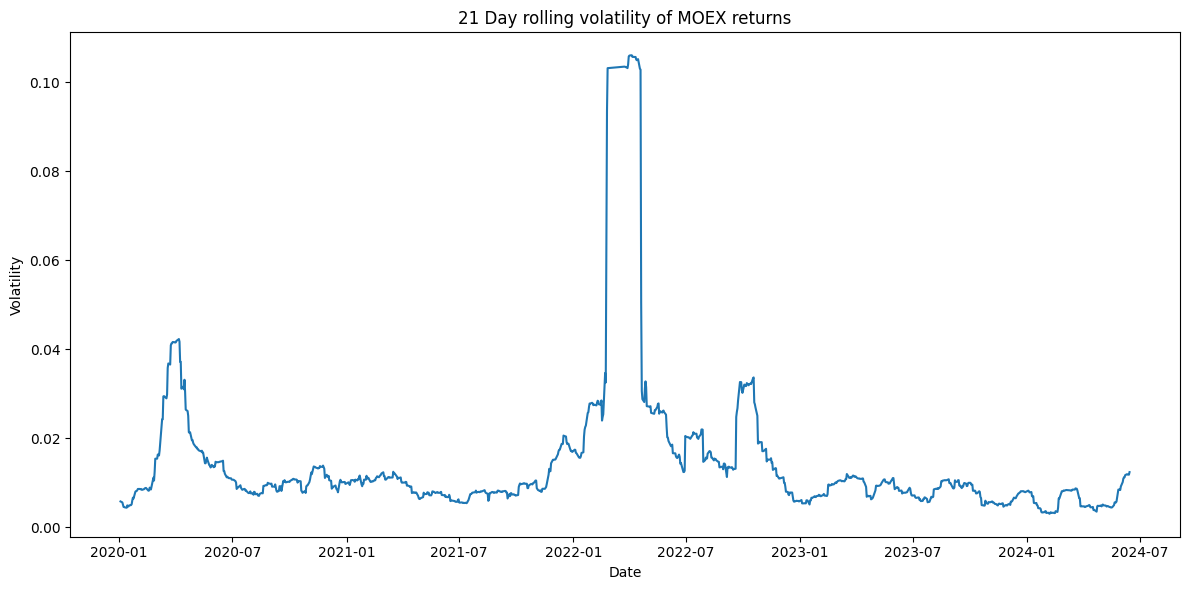

correlation.png		 OxCGRT_nat_latest.csv.2  panel_dataset_2020_2025.csv
moexbrent.png		 OxCGRT_nat_latest.csv.3  returns.png
OxCGRT_nat_latest.csv	 OxCGRT_nat_latest.csv.4  sample_data
OxCGRT_nat_latest.csv.1  paneldataset2020,2025	  volatility.png


In [14]:
plt.figure(figsize=(12,6))
plt.plot(moexdata["Date"], moexdata["volatility_21d"])
plt.title("21 Day rolling volatility of MOEX returns")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.tight_layout()
plt.savefig("volatility.png",dpi=300,bbox_inches="tight")
plt.show()
!ls
from google.colab import files
##files.download('/content/volatility.png')

In [15]:
moexdata["d_Brent"]=moexdata["Brent"].diff()
moexdata["d_DXY"]=moexdata["DXY"].diff()
moexdata["d_VIX"]=moexdata["VIX"].diff()
moexdata["d_US10Y"]=moexdata["US10Y"].diff()
moexdata["d_COVID"]=moexdata["COVID_Stringency"].diff()
moexdata=moexdata.dropna()

In [16]:
X=moexdata[["d_VIX","d_Brent","d_DXY","d_US10Y","d_COVID"]]
X=sm.add_constant(X)
y=moexdata["returns"]
model = sm.OLS(y, X).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 5})
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                returns   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     11.19
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           1.53e-10
Time:                        11:51:27   Log-Likelihood:                 2793.1
No. Observations:                1101   AIC:                            -5574.
Df Residuals:                    1095   BIC:                            -5544.
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.644e-05      0.001      0.109      0.9

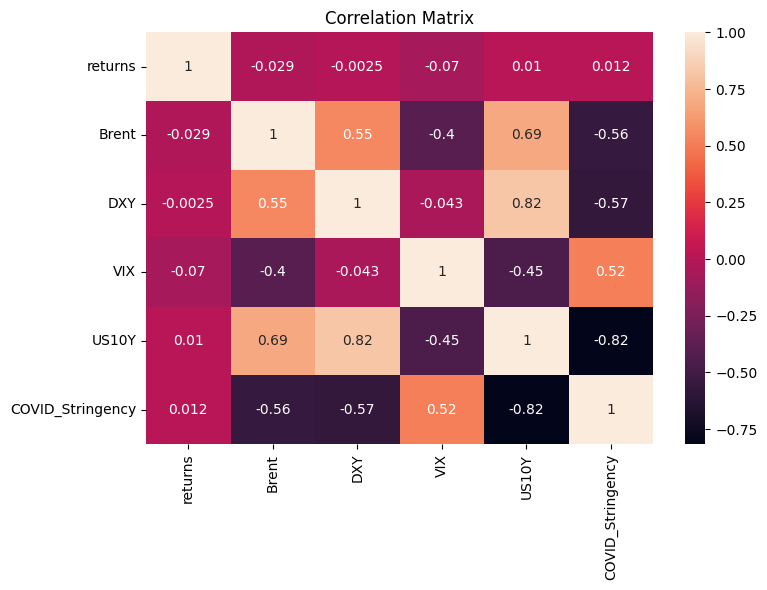

In [17]:
import seaborn as sns
corr = moexdata[["returns","Brent","DXY","VIX","US10Y","COVID_Stringency"]].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("correlation.png", dpi=300, bbox_inches="tight")
plt.show()
##files.download("correlation.png")

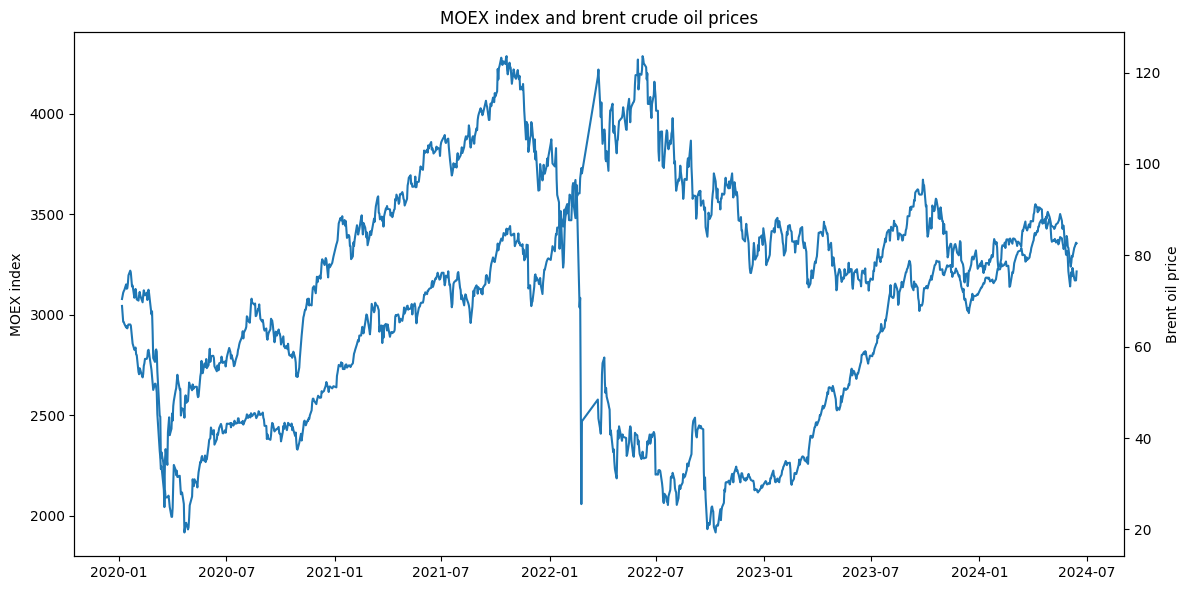

In [18]:
fig, ax1 = plt.subplots(figsize=(12,6))
ax1.plot(moexdata["Date"], moexdata["Close"])
ax1.set_ylabel("MOEX index")
ax2 = ax1.twinx()
ax2.plot(moexdata["Date"], moexdata["Brent"])
ax2.set_ylabel("Brent oil price")
plt.title("MOEX index and brent crude oil prices")
plt.tight_layout()
plt.savefig("moexbrent.png", dpi=300, bbox_inches="tight")
plt.show()
##files.download("moexbrent.png")

In [19]:
## Начало тестов (ADF)
from statsmodels.tsa.stattools import adfuller
def adftesting(series, name):
    result = adfuller(series.dropna())
    print(f"ADF {name}")
    print("ADF statistic", result[0])
    print("pval:", result[1])
    print("-" * 40)
adftesting(moexdata["Close"], "MOEX level")
adftesting(moexdata["Brent"], "Brent")
adftesting(moexdata["DXY"], "DXY")
adftesting(moexdata["VIX"], "VIX")
adftesting(moexdata["returns"], "MOEX returns")
display(moexdata.describe())

ADF MOEX level
ADF statistic -1.399697417557936
pval: 0.5824211717496086
----------------------------------------
ADF Brent
ADF statistic -1.3204029040091712
pval: 0.6197870415652585
----------------------------------------
ADF DXY
ADF statistic -1.0865576363910803
pval: 0.7204026863656471
----------------------------------------
ADF VIX
ADF statistic -4.1216274182543
pval: 0.0008918011818479784
----------------------------------------
ADF MOEX returns
ADF statistic -37.13668288941926
pval: 0.0
----------------------------------------


,Date,Close,returns,volatility_21d,VIX,Brent,DXY,US10Y,COVID_Stringency,d_Brent,d_DXY,d_VIX,d_US10Y,d_COVID
count,1101,1101.000000,1101.000000,1101.000000,1101.000000,1101.000000,1101.000000,1101.000000,1101.000000,1101.000000,1101.000000,1101.000000,1101.000000,1101.000000
mean,2022-03-27 23:50:50.681198848,3012.193633,0.000040,0.013605,21.722525,74.261789,99.515740,2.525484,31.357221,0.012734,0.007911,-0.001235,0.002203,0.010091
min,2020-01-06 00:00:00,1916.969971,-0.404674,0.003054,11.860000,19.330000,89.440002,0.515000,0.000000,-9.980003,-2.809998,-17.639999,-0.322000,-27.770000
25%,2021-02-11 00:00:00,2525.969971,-0.005150,0.007557,16.200001,63.209999,93.550003,1.302000,11.110000,-0.790001,-0.230003,-0.810001,-0.033000,0.000000
50%,2022-04-08 00:00:00,3079.500000,0.001249,0.009702,20.090000,78.519997,100.389999,2.642000,31.020000,0.080002,0.000000,-0.100000,0.000000,0.000000
75%,2023-05-15 00:00:00,3439.110107,0.007014,0.013968,25.510000,86.239998,104.160004,3.850000,47.690000,0.989998,0.240005,0.650000,0.039000,0.000000
max,2024-06-14 00:00:00,4287.520020,0.182619,0.106094,82.690002,123.580002,114.110001,4.988000,87.040000,21.099998,2.169998,24.860001,0.355000,24.540000
std,NaN,579.451913,0.019903,0.014605,8.411327,20.940184,5.912059,1.385421,20.695833,1.855498,0.460196,2.185779,0.064525,2.145952


In [20]:
## DOLS
from statsmodels.tsa.stattools import adfuller
dolsdata = moexdata[['Close','Brent','DXY','US10Y']].copy().dropna()
Ydols = dolsdata['Close']
Xdols = dolsdata[['Brent', 'DXY', 'US10Y']].copy()
for col in ['Brent', 'DXY', 'US10Y']:
    Xdols[f'{col}_d']=Xdols[col].diff()
    Xdols[f'{col}_d_lag']=Xdols[col].diff().shift(1)
    Xdols[f'{col}_d_lead'] = Xdols[col].diff().shift(-1)
Xdols=Xdols.dropna()
Ydols= Ydols.loc[Xdols.index]
Xdols= sm.add_constant(Xdols)
Dolsmod = sm.OLS(Ydols, Xdols).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
print(Dolsmod.summary())
residuals1= Dolsmod.resid
adfres2 =adfuller(residuals1, regression='c', autolag='AIC')
print(f"\nstat = {adfres2[0]:.4f}, p-value = {adfres2[1]:.4f}")
print(f"crit values: {adfres2[4]}")
if adfres2[1] < 0.05:
    print("cointegration (α=0.05)")
elif adfres2[1] < 0.10:
    print("weak cointegration (α=0.10))")
else:
    print("no cointegration")

                            OLS Regression Results                            
Dep. Variable:                  Close   R-squared:                       0.563
Model:                            OLS   Adj. R-squared:                  0.558
Method:                 Least Squares   F-statistic:                     45.58
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           1.14e-87
Time:                        11:51:35   Log-Likelihood:                -8090.2
No. Observations:                1098   AIC:                         1.621e+04
Df Residuals:                    1085   BIC:                         1.627e+04
Df Model:                          12                                         
Covariance Type:                  HAC                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1.384e+04    482.452     28.689   

In [21]:
## ADF на остатках DOLS
residuals = Dolsmod.resid
adfresu = adfuller(residuals, regression='c', autolag='AIC')
print(f"ADF statistic on DOLS residuals: {adfresu[0]:.4f}")
print(f"p-value: {adfresu[1]:.4f}")
print(f"Crit values: {adfresu[4]}")
if adfresu[1] < 0.05:
    print("\n the residuals are stationary - co-integration. Hypothesis 2 (H1) is confirmed: long-term equilibrium.")
else:
    print("\n the residuals are non-stationary - no co-integration. Hypothesis 2 (H0) is not rejected.")

ADF statistic on DOLS residuals: -2.6428
p-value: 0.0845
Crit values: {'1%': np.float64(-3.436341508283391), '5%': np.float64(-2.864185524365606), '10%': np.float64(-2.5681785627437677)}

 the residuals are non-stationary - no co-integration. Hypothesis 2 (H0) is not rejected.


In [22]:
#№ BAI-PERRON
!pip install ruptures -q
import ruptures as rpt
dolsdate = moexdata.set_index('Date')[['Close','Brent','DXY','US10Y']].dropna()
residualsser = pd.Series(
    Dolsmod.resid.values,
    index=dolsdate.index[2:-1])
print(f"Residuals length: {len(Dolsmod.resid)}, restored dates: {len(residualsser)}")
signal = Dolsmod.resid.values.reshape(-1, 1)
for penvalue in [30, 50, 100]:
    algor = rpt.Pelt(model="rbf").fit(signal)
    bps = algor.predict(pen=penvalue)
    print(f"pen={penvalue}: {len(bps)-1} breakpoint, index: {bps[:-1]}")

Residuals length: 1098, restored dates: 1098
pen=30: 4 breakpoint, index: [125, 360, 530, 885]
pen=50: 4 breakpoint, index: [125, 360, 530, 885]
pen=100: 0 breakpoint, index: []


Index  125 - Date: 2020-07-13
Index  360 - Date: 2021-06-18
Index  530 - Date: 2022-02-16
Index  885 - Date: 2023-08-10


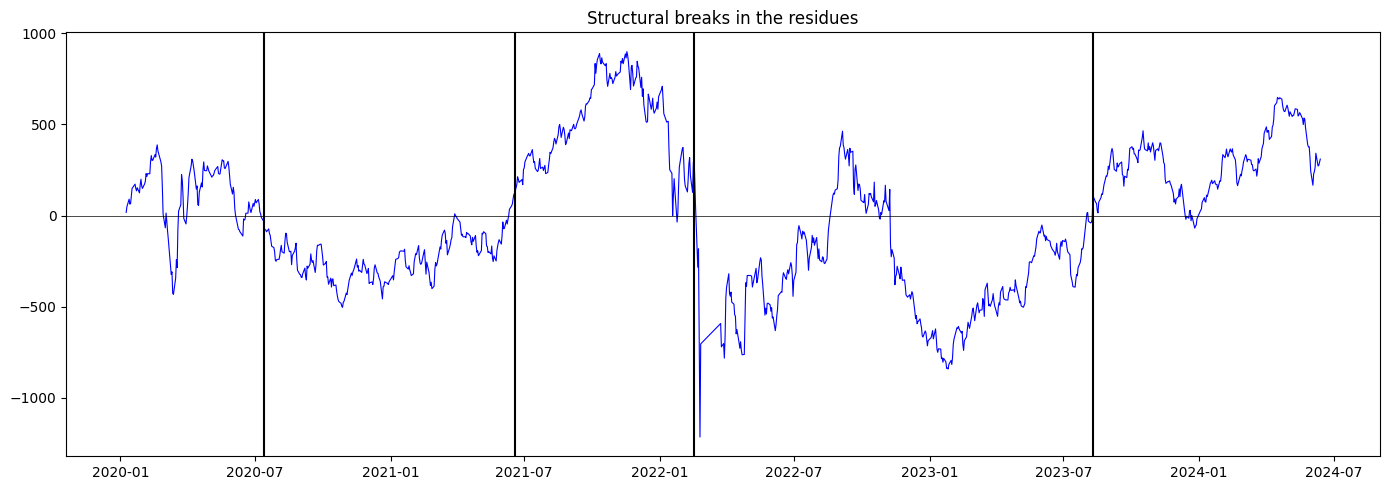

In [23]:
## Декодирование дат разрывов
breakpoints_idx = [125, 360, 530, 885]
for idx in breakpoints_idx:
    date = residualsser.index[idx]
    print(f"Index {idx:4d} - Date: {date.date()}")
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(residualsser.index, Dolsmod.resid.values, color='blue', linewidth=0.8, label='DOLS residuals')
colors = ['black', 'black', 'black', 'black']
for i, idx in enumerate(breakpoints_idx):
    date = residualsser.index[idx]
    ax.axvline(x=date, color=colors[i], linestyle='-', linewidth=1.5,label=f'Break {i+1}: {date.date()}')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Structural breaks in the residues')
plt.tight_layout()
plt.show()

In [24]:
## раздельный DOLS
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
BreakDate = "2022.02.16"
def dolssubperiod(data, label):
    D = data[['Close', 'Brent', 'DXY', 'US10Y']].copy().dropna()
    Y = D['Close']
    X = D[['Brent', 'DXY', 'US10Y']].copy()
    for col in ['Brent', 'DXY', 'US10Y']:
        X[f'{col}_d'] = X[col].diff()
        X[f'{col}_d_lag'] = X[col].diff().shift(1)
        X[f'{col}_d_lead'] = X[col].diff().shift(-1)
    X=X.dropna()
    Y = Y.loc[X.index]
    X=sm.add_constant(X)
    model= sm.OLS(Y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
    resid = model.resid
    adfr = adfuller(resid, regression='c', autolag='AIC')
    print(f"DOLS subperiod: {label}  (N={len(Y)})")
    params = model.params[['const','Brent','DXY','US10Y']]
    pvals = model.pvalues[['const','Brent','DXY','US10Y']]
    print(f"{'Variable':10} | {'coef.':>10} | {'p-value':>10}")
    for v in ['const','Brent','DXY','US10Y']:
        print(f"{v:10} | {params[v]:>10.3f} | {pvals[v]:>10.4f}")
    print(f"\nR² = {model.rsquared:.4f} | Durbin-Watson = {sm.stats.stattools.durbin_watson(resid):.4f}")
    print(f"ADF on residues: stat={adfr[0]:.4f}, p-value={adfr[1]:.4f}")
    if adfr[1] < 0.05:
        print("cointegration (α=0.05)")
    elif adfr[1] < 0.10:
        print("weak cointegration (α=0.10)")
    else:
        print("no cointegration")
    return model
beforebreak = moexdata[moexdata['Date'] < BreakDate].copy()
afterbreak = moexdata[moexdata['Date'] >= BreakDate].copy()
print(f"Period before: {beforebreak['Date'].min().date()} — {beforebreak['Date'].max().date()} (N={len(beforebreak)})")
print(f"Period after: {afterbreak['Date'].min().date()} — {afterbreak['Date'].max().date()} (N={len(afterbreak)})")
modelbefore = dolssubperiod(beforebreak, f"bedore {BreakDate}")
modelafter = dolssubperiod(afterbreak, f"after {BreakDate}")
print("comparison of long-term coefficients by period")
print(f"{'Variable':12} | {'Before shock':>10} | {'After shock':>10} | {'Change':>10} | p-value (post)")
for var in ['Brent', 'DXY', 'US10Y']:
    coefbefore = modelbefore.params.get(var,  float('nan'))
    coefafter = modelafter.params.get(var, float('nan'))
    pvalafter = modelafter.pvalues.get(var, float('nan'))
    delta = coefafter - coefbefore
    sig = "**" if pvalafter < 0.05 else ("*" if pvalafter < 0.10 else "н/з")
    print(f"{var:12} | {coefbefore:>10.3f} | {coefafter:>10.3f} | {delta:>+10.3f} | {pvalafter:.4f} {sig}")

Period before: 2020-01-06 — 2022-02-15 (N=532)
Period after: 2022-02-16 — 2024-06-14 (N=569)
DOLS subperiod: bedore 2022.02.16  (N=529)
Variable   |      coef. |    p-value
const      |   4576.863 |     0.0000
Brent      |     28.042 |     0.0000
DXY        |    -28.195 |     0.0000
US10Y      |   -193.937 |     0.0003

R² = 0.8696 | Durbin-Watson = 0.0660
ADF on residues: stat=-2.1013, p-value=0.2440
no cointegration
DOLS subperiod: after 2022.02.16  (N=566)
Variable   |      coef. |    p-value
const      |   8111.836 |     0.0000
Brent      |      8.335 |     0.0000
DXY        |    -85.299 |     0.0000
US10Y      |    733.198 |     0.0000

R² = 0.7102 | Durbin-Watson = 0.0771
ADF on residues: stat=-5.1006, p-value=0.0000
cointegration (α=0.05)
comparison of long-term coefficients by period
Variable     | Before shock | After shock |     Change | p-value (post)
Brent        |     28.042 |      8.335 |    -19.707 | 0.0000 **
DXY          |    -28.195 |    -85.299 |    -57.104 | 0.0000 

In [25]:
## Для первой гипотезы: краткосрочная OLS и струк разрывы
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.formula.api as smf
moexret = moexdata.dropna(subset=['returns', 'Brent', 'DXY', 'VIX', 'US10Y', 'COVID_Stringency']).copy()
moexret['d_Brent'] = moexret['Brent'].diff()
moexret['d_DXY'] = moexret['DXY'].diff()
moexret['d_US10Y'] = moexret['US10Y'].diff()
moexret = moexret.dropna()
featuresols = ['d_Brent', 'd_DXY', 'VIX', 'd_US10Y', 'COVID_Stringency']
Xols = sm.add_constant(moexret[featuresols])
Yols = moexret['returns']
olsfull = sm.OLS(Yols, Xols).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
print(olsfull.summary())
dw = durbin_watson(olsfull.resid)
print(f"\nDurbin-Watson: {dw:.4f}  (норма ~2.0, <1.5 = автокорреляция)")
bptest = het_breuschpagan(olsfull.resid, olsfull.model.exog)
print(f"Breusch-Pagan test")
print(f"LM stat={bptest[0]:.4f}, p-value={bptest[1]:.4f}")
if bptest[1] < 0.05:
    print("heteroskedasticity is present so HAC SE is justified")
else:
    print("there is no heteroscedasticity")
from scipy.stats import jarque_bera
jbstat, jbpval = jarque_bera(olsfull.resid)
print(f"\nJarque-Bera: stat={jbstat:.4f}, p-value={jbpval:.4f}")
if jbpval < 0.05:
    print("the residues are not normal, HAC needs to be used")

                            OLS Regression Results                            
Dep. Variable:                returns   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     5.993
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           1.76e-05
Time:                        11:51:52   Log-Likelihood:                 2771.5
No. Observations:                1100   AIC:                            -5531.
Df Residuals:                    1094   BIC:                            -5501.
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0026      0.002  

breakpoints:
break 1: index=470, date=2021-11-18
break 2: index=690, date=2022-10-28

breakpoints resistance:
pen=  5: 2 breakpoints - [datetime.date(2021, 11, 18), datetime.date(2022, 10, 28)]
pen= 10: 2 breakpoints - [datetime.date(2021, 11, 18), datetime.date(2022, 10, 28)]
pen= 20: 0 breakpoints - []
pen= 30: 0 breakpoints - []


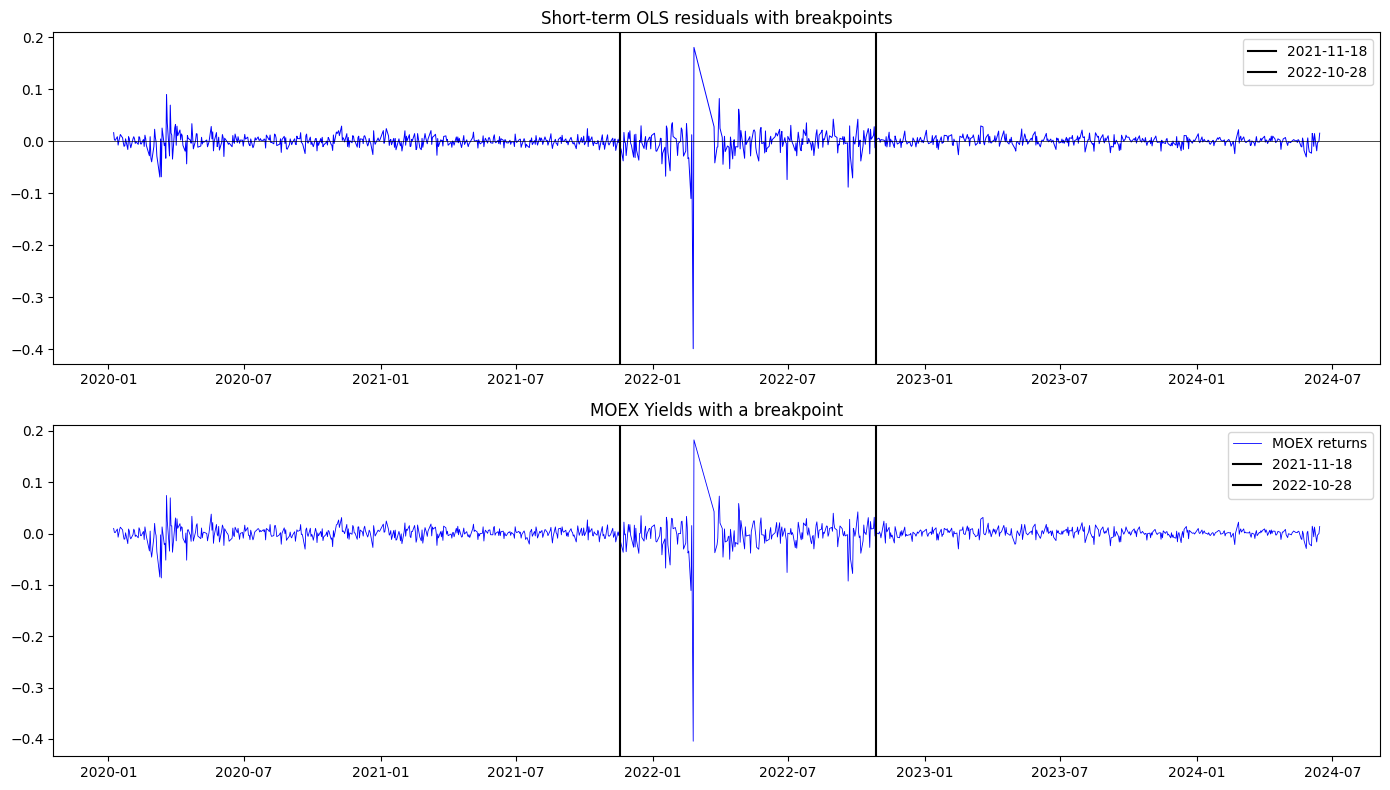


Chow breakpoint test: 24.02.2022
Before breakingpoint: N=536
After: N=564

Chow F-stat: 4.8527
p-value: 0.000067
number of restrictions: k=6
H0 is rejected so there is a structural break (24.02.2022)
the coefficients of the short-term model changed significantly after the shock, which confirms H1


In [26]:
## Для первой гипотезы: структ разрывы в кратсрок OLS
import ruptures as rpt
from scipy.stats import f as f_dist
datesret = pd.to_datetime(moexret['Date'].values)
signalret = olsfull.resid.values.reshape(-1, 1)
algoret = rpt.Pelt(model="rbf").fit(signalret)
bpretind = algoret.predict(pen=5)
bpretdate = []
for i in bpretind:
    if i < len(datesret):
        bpretdate.append(datesret[i-1])
print(f"breakpoints:")
for i, (idx, d) in enumerate(zip(bpretind, bpretdate)):
    print(f"break {i+1}: index={idx}, date={pd.Timestamp(d).date()}")
print("\nbreakpoints resistance:")
for penvalue in [5, 10, 20, 30]:
    bps = rpt.Pelt(model="rbf").fit(signalret).predict(pen=penvalue)
    datesgotthem = [pd.Timestamp(datesret[i-1]).date()
                   for i in bps if i < len(datesret)]
    print(f"pen={penvalue:3d}: {len(bps)-1} breakpoints - {datesgotthem}")
residvals = olsfull.resid.values
retvals = moexret['returns'].values
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(datesret, residvals, color='blue', linewidth=0.7)
for d in bpretdate: axes[0].axvline(x=pd.Timestamp(d), color='black', linestyle='-',linewidth=1.5, label=f'{pd.Timestamp(d).date()}')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('Short-term OLS residuals with breakpoints')
axes[0].legend()
axes[1].plot(datesret, retvals, color='blue', linewidth=0.6, label='MOEX returns')
for d in bpretdate:
    axes[1].axvline(x=pd.Timestamp(d), color='black', linestyle='-', linewidth=1.5, label=f'{pd.Timestamp(d).date()}')
axes[1].set_title('MOEX Yields with a breakpoint')
axes[1].legend()
plt.tight_layout()
plt.show()
print("\nChow breakpoint test: 24.02.2022")
ChowDate = "2022.02.24"
beforechow = moexret[moexret['Date'] < ChowDate].copy()
afterchow = moexret[moexret['Date'] >= ChowDate].copy()
print(f"Before breakingpoint: N={len(beforechow)}")
print(f"After: N={len(afterchow)}")
def ols_rss(df):
    X = sm.add_constant(df[featuresols])
    y = df['returns']
    m = sm.OLS(y, X).fit()
    return m.ssr, len(df), X.shape[1]
rssbefore, n1, k = ols_rss(beforechow)
rssafter, n2, _ = ols_rss(afterchow)
rssfullval, _, _ = ols_rss(moexret)
fchow = ((rssfullval - (rssbefore + rssafter)) / k) / ((rssbefore + rssafter) / (n1 + n2 - 2*k))
pchow = 1 - f_dist.cdf(fchow, k, n1 + n2 - 2*k)
print(f"\nChow F-stat: {fchow:.4f}")
print(f"p-value: {pchow:.6f}")
print(f"number of restrictions: k={k}")
if pchow < 0.05:
    print("H0 is rejected so there is a structural break (24.02.2022)")
    print("the coefficients of the short-term model changed significantly after the shock, which confirms H1")
else:
    print("H0 is not rejected at 0.05")

lengths after alignment: dates=1086, cusum=1086, upper=1086, lower=1086


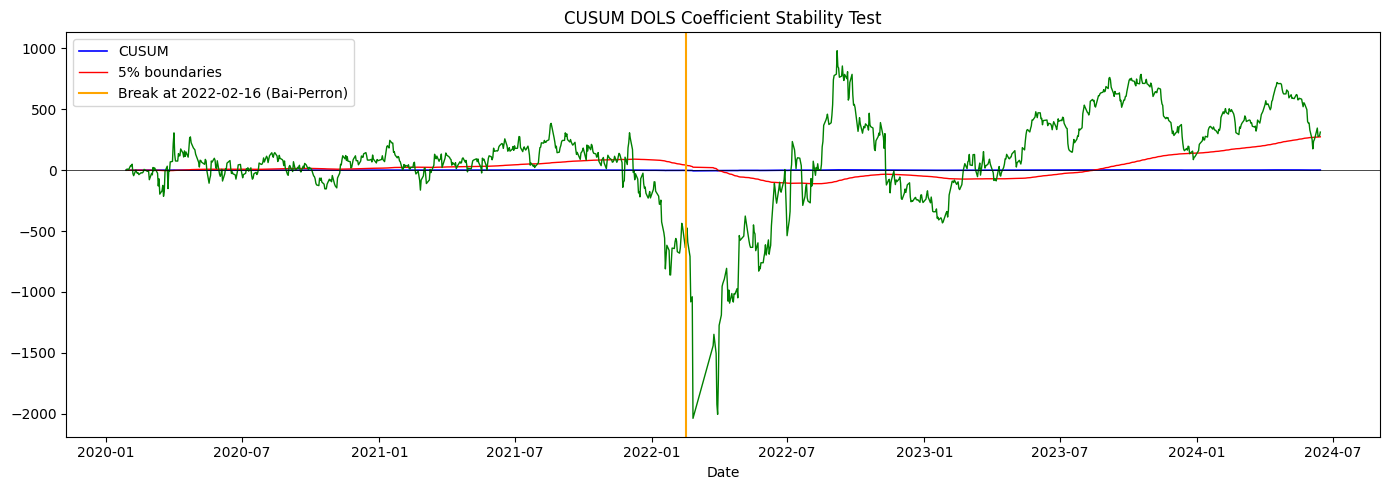

first time out of boundaries: 2020-01-29

CUSUM goes beyond 5%-limits: True
H0 is rejected: long-term coefficients are unstable
as a result, Hypothesis 3 is confirmed, geopolitical shocks have changed the long-term equilibrium of MOEX with macro factors


In [27]:
## Гипотеза H3 CUSUM НА DOLS
from statsmodels.stats.diagnostic import recursive_olsresiduals
cusumresult = recursive_olsresiduals(Dolsmod)
cusumstat = cusumresult[3]
cusumupper= cusumresult[5]
cusumlower= cusumresult[4]
minilen =min(len(cusumstat), len(cusumupper), len(cusumlower))
cusumstat= cusumstat[-minilen:]
cusumupper= cusumupper[-minilen:]
cusumlower= cusumlower[-minilen:]
dolsdatesc = dolsdate.index[-minilen:]
print(f"lengths after alignment: dates={len(dolsdatesc)}, "
      f"cusum={len(cusumstat)}, upper={len(cusumupper)}, lower={len(cusumlower)}")
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dolsdatesc, cusumstat, color='blue', linewidth=1.2, label='CUSUM')
ax.plot(dolsdatesc, cusumupper,color='red', linewidth=1.0,linestyle='-', label='5% boundaries')
ax.plot(dolsdatesc, cusumlower, color='green', linewidth=1.0,linestyle='-')
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(x=pd.Timestamp("2022-02-16"), color='orange', linewidth=1.5, linestyle='-', label='Break at 2022-02-16 (Bai-Perron)')
ax.set_title('CUSUM DOLS Coefficient Stability Test')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()
exceeded = np.any(cusumstat > cusumupper) or np.any(cusumstat < cusumlower)
for i in range(minilen):
    if cusumstat[i] > cusumupper[i] or cusumstat[i] < cusumlower[i]:
        print(f"first time out of boundaries: {dolsdatesc[i].date()}")
        break
print(f"\nCUSUM goes beyond 5%-limits: {exceeded}")
if exceeded:
    print("H0 is rejected: long-term coefficients are unstable")
    print("as a result, Hypothesis 3 is confirmed, geopolitical shocks have changed the long-term equilibrium of MOEX with macro factors")
else:
    print("H0 is not rejected")

In [28]:
print(f"{'Hypothesis':<16} | {'test':<30} | {'Result'}")
print(f"{'H1':<16} | {'Chow test (24.02.2022)':<30} | good(confirmed) (p=0.000067)")
print(f"{'H1':<16} | {'Bai-Perron (ruptures)':<30} | weak gap (pen≤10)")
print(f"{'H2 (full)':<16} | {'ADF on DOLS residuals':<30} | not confirmed (p=0.070)")
print(f"{'H2 (before 2022)':<16} | {'ADF on DOLS residuals':<30} | false regression (p=0.244)")
print(f"{'H2 (after 2022)':<16} | {'ADF on DOLS residuals':<30} | confirmed (p=0.000)")
print(f"{'H3':<16} | {'CUSUM на DOLS':<30} | prev")
print(f"{'H3':<16} | {'coefficients changing':<30} | all three p<0.05")

Hypothesis       | test                           | Result
H1               | Chow test (24.02.2022)         | good(confirmed) (p=0.000067)
H1               | Bai-Perron (ruptures)          | weak gap (pen≤10)
H2 (full)        | ADF on DOLS residuals          | not confirmed (p=0.070)
H2 (before 2022) | ADF on DOLS residuals          | false regression (p=0.244)
H2 (after 2022)  | ADF on DOLS residuals          | confirmed (p=0.000)
H3               | CUSUM на DOLS                  | prev
H3               | coefficients changing          | all three p<0.05


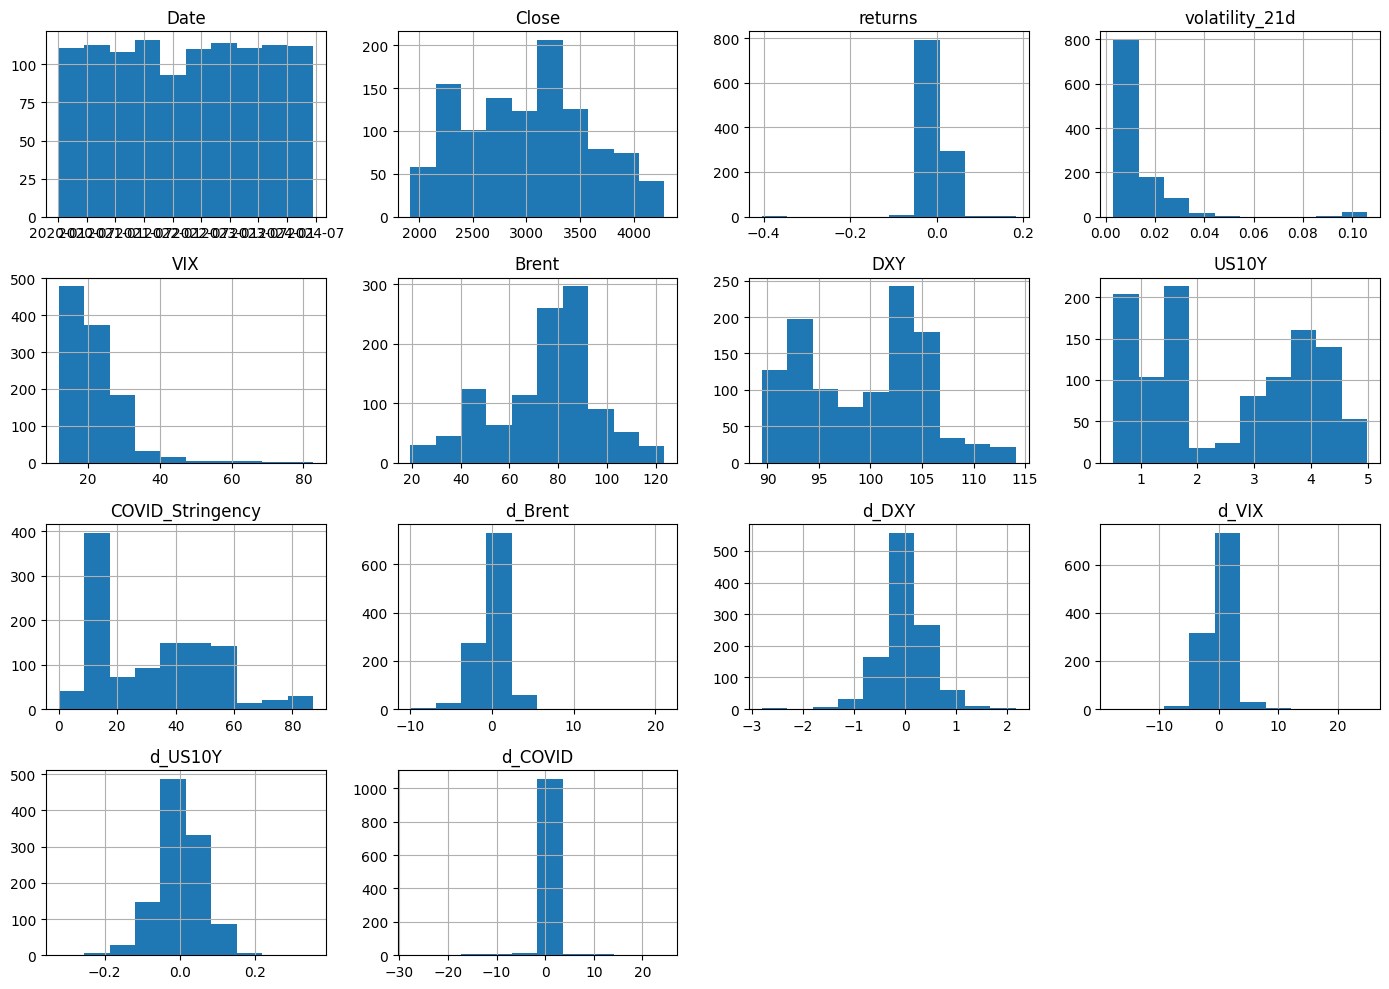

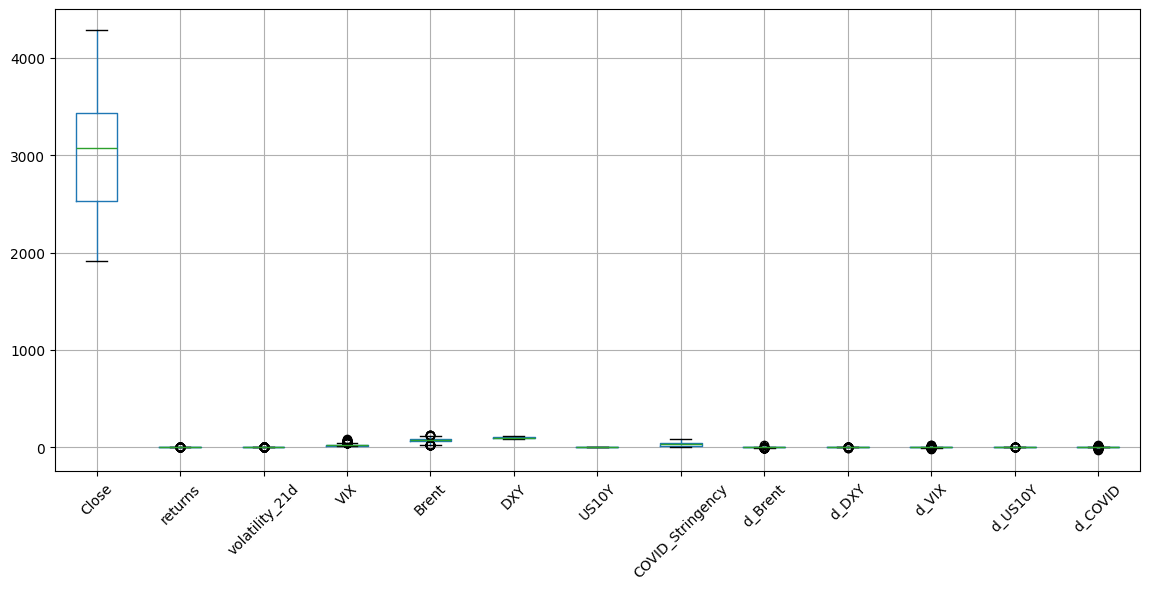

In [29]:
moexdata.hist(figsize=(14,10))
plt.tight_layout()
plt.show()
plt.figure(figsize=(14,6))
moexdata.boxplot()
plt.xticks(rotation=45)
plt.show()

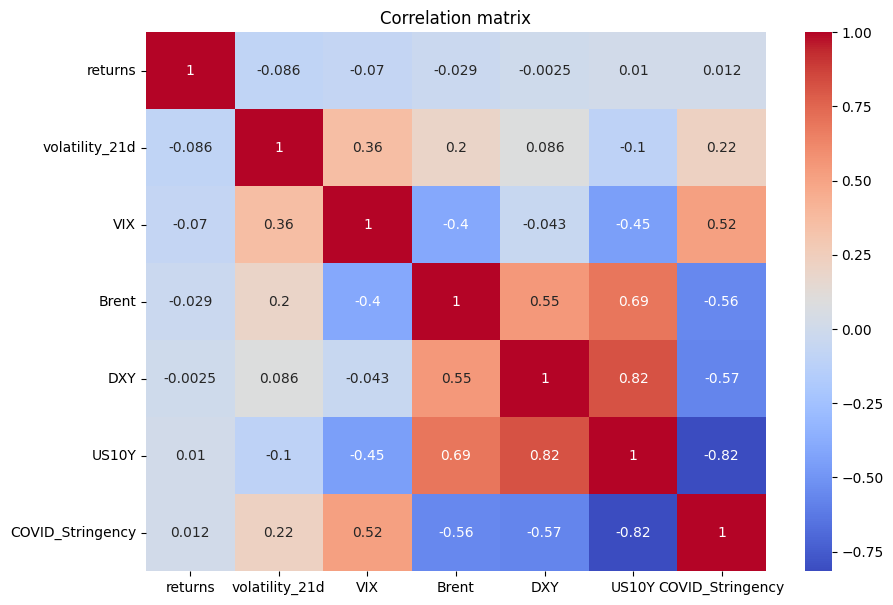

In [30]:
corrvars =["returns","volatility_21d","VIX","Brent","DXY","US10Y","COVID_Stringency"]
corrmatrix= moexdata[corrvars].corr()
plt.figure(figsize=(10,7))
sns.heatmap(corrmatrix, annot=True, cmap="coolwarm")
plt.title("Correlation matrix")
plt.show()

In [31]:
moexdata["d_Brent"]=moexdata["Brent"].diff()
moexdata["d_DXY"]=moexdata["DXY"].diff()
moexdata["d_VIX"]=moexdata["VIX"].diff()
moexdata["d_US10Y"]=moexdata["US10Y"].diff()
moexdata["d_COVID"]=moexdata["COVID_Stringency"].diff()
moexdata=moexdata.dropna()

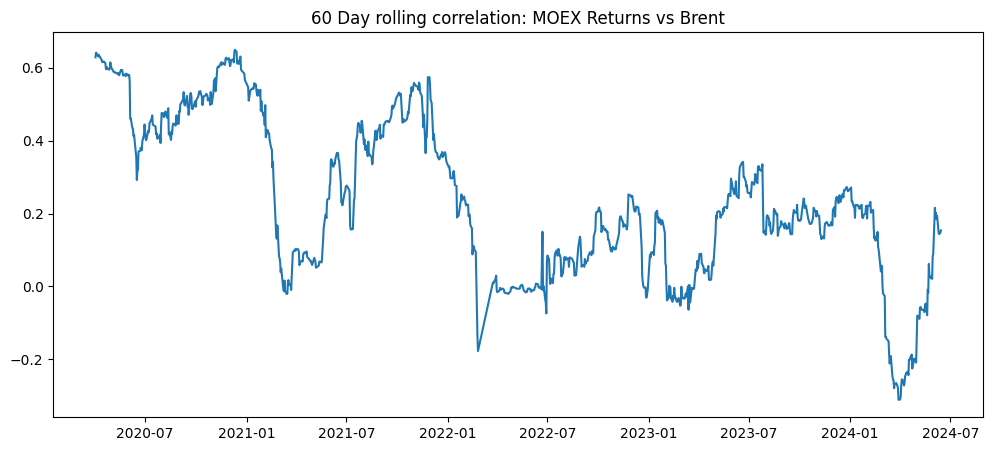

In [32]:
rollingcorr=moexdata["returns"].rolling(60).corr(moexdata["d_Brent"])
plt.figure(figsize=(12,5))
plt.plot(moexdata["Date"], rollingcorr)
plt.title("60 Day rolling correlation: MOEX Returns vs Brent")
plt.show()

In [33]:
X =moexdata[["VIX","Brent","DXY","US10Y","COVID_Stringency"]]
X =sm.add_constant(X)
y =moexdata["returns"]
model =sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                returns   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     3.121
Date:                Tue, 02 Jun 2026   Prob (F-statistic):            0.00837
Time:                        11:52:30   Log-Likelihood:                 2755.5
No. Observations:                1100   AIC:                            -5499.
Df Residuals:                    1094   BIC:                            -5469.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.0148      0.019  

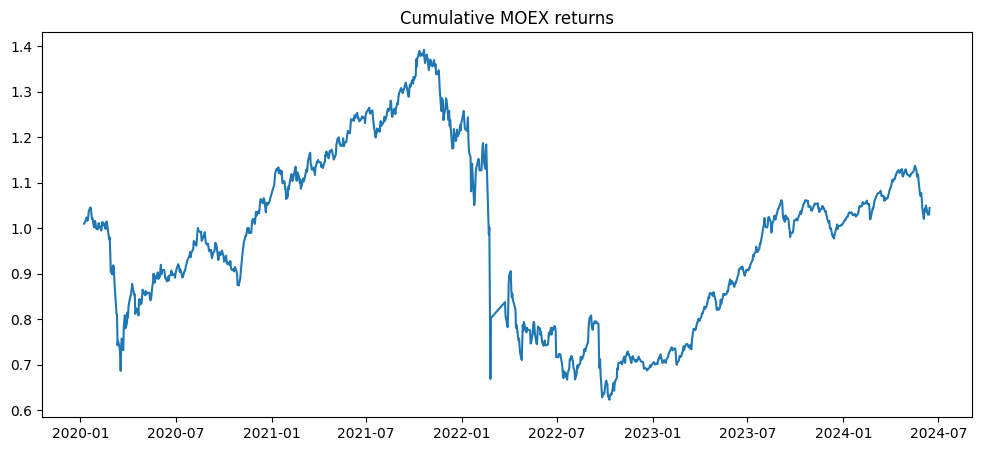

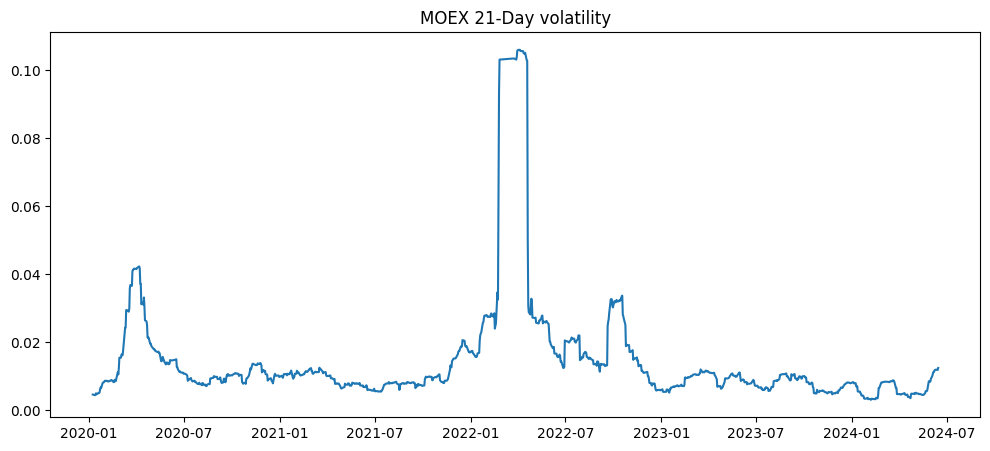

In [34]:
moexdata["cum_returns"] = np.exp(moexdata["returns"].cumsum())
plt.figure(figsize=(12,5))
plt.plot(moexdata["Date"], moexdata["cum_returns"])
plt.title("Cumulative MOEX returns")
plt.show()
plt.figure(figsize=(12,5))
plt.plot(moexdata["Date"], moexdata["volatility_21d"])
plt.title("MOEX 21-Day volatility")
plt.show()

In [35]:
paneldata.to_csv("paneldataset2020,2025", index=False)
from google.colab import files
##files.download("paneldataset2020,2025")

In [36]:
paneldata.isna().sum().sum()

np.int64(0)

In [37]:
## Модели
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error as meanabsoluterror, mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings("ignore")

In [38]:
moexmlmod = moexdata.dropna(subset=['returns','Brent','DXY','VIX','US10Y','COVID_Stringency']).copy().reset_index(drop=True)
features = ['Brent', 'DXY', 'VIX', 'US10Y', 'COVID_Stringency']
Xa =moexmlmod[features].values
Ya =moexmlmod['returns'].values
dates = moexmlmod['Date'].values
n =len(moexmlmod)
holdout_size = int(n * 0.15)
Xdev, Xholout = Xa[:-holdout_size], Xa[-holdout_size:]
Ydev, Yholout = Ya[:-holdout_size], Ya[-holdout_size:]
print(f"total observations: {n}")
print(f"development set (train and val): {len(Ydev)} obs ({len(Ydev)/n*100:.0f}%)")
print(f"hold-out test set:{holdout_size} obs ({holdout_size/n*100:.0f}%) - untouched until final evaluation\n")
print("walk-forward cross-validation on development set")
tscv = TimeSeriesSplit(n_splits=5)
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
alphascor = {a: [] for a in alphas}
for tridx, validx in tscv.split(Xdev):
    Xtrainn, Xval = Xdev[tridx], Xdev[validx]
    Ytrainn, Yval = Ydev[tridx], Ydev[validx]
    for a in alphas:
        m = Ridge(alpha=a).fit(Xtrainn, Ytrainn)
        alphascor[a].append(meanabsoluterror(Yval, m.predict(Xval)))
maxialpha = min(alphas, key=lambda a: np.mean(alphascor[a]))
print(f"ridge alpha candidates: {alphas}")
print(f"best alpha (lowest avg MAE on val folds): {maxialpha}\n")
print("Walk-Forward fold periods")
for fold, (tridx, validx) in enumerate(tscv.split(Xdev)):
    traindate = dates[tridx]
    valdate = dates[validx]
    print(f"fold {fold+1}:")
    print(f"train: {pd.Timestamp(traindate[0]).date()} - "f"{pd.Timestamp(traindate[-1]).date()} (N={len(tridx)})")
    print(f"val: {pd.Timestamp(valdate[0]).date()} - "f"{pd.Timestamp(valdate[-1]).date()} (N={len(validx)})")
holoutdate = dates[-holdout_size:]
print(f"\nHold-out: {pd.Timestamp(holoutdate[0]).date()} - "f"{pd.Timestamp(holoutdate[-1]).date()} (N={holdout_size})\n")
print(f"{'Fold':>4} | {'Train N':>7} | {'Val N':>5} | "f"{'Model':20} | {'MAE':>8} | {'RMSE':>8} | {'R²':>8}")
resultsdev = []
for fold, (tridx, validx) in enumerate(tscv.split(Xdev)):
    Xtrainn,Xval = Xdev[tridx], Xdev[validx]
    Ytrainn,Yval = Ydev[tridx], Ydev[validx]
    modelsfold=[
        ("OLS", LinearRegression().fit(Xtrainn, Ytrainn)),
        (f"Ridge (α={maxialpha})", Ridge(alpha=maxialpha).fit(Xtrainn, Ytrainn)),]
    for name, model in modelsfold:
        pred= model.predict(Xval)
        mae =meanabsoluterror(Yval, pred)
        rmse = np.sqrt(mean_squared_error(Yval, pred))
        r2= r2_score(Yval, pred)
        resultsdev.append({'fold': fold+1, 'model': name,'MAE': mae, 'RMSE': rmse, 'R2': r2})
        nlbl = f"{len(tridx):>7}" if name == "OLS" else " " * 7
        vlbl = f"{len(validx):>5}" if name == "OLS" else " " * 5
        print(f"{fold+1:4} | {nlbl} | {vlbl} | {name:20} | "f"{mae:.5f} | {rmse:.5f} | {r2:.4f}")






    prednaive = np.zeros(len(Yval))
    maen = meanabsoluterror(Yval, prednaive)
    rmsen = np.sqrt(mean_squared_error(Yval, prednaive))
    r2n = r2_score(Yval, prednaive)
    resultsdev.append({'fold': fold+1, 'model': 'Naive (0)','MAE': maen, 'RMSE': rmsen, 'R2': r2n})
    print(f"{fold+1:4} | {'':>7} | {'':>5} | {'Naive (0)':20} | "f"{maen:.5f} | {rmsen:.5f} | {r2n:.4f}")
print("\n average metricks")
summary = (pd.DataFrame(resultsdev).groupby('model')[['MAE','RMSE','R2']].mean().round(5))
print(summary)
print("\n evaluation on hold-out test set")
olsfin = LinearRegression().fit(Xdev, Ydev)
ridgefina = Ridge(alpha=maxialpha).fit(Xdev, Ydev)
holoutres = []
for name, pred in [("OLS", olsfin.predict(Xholout)),(f"Ridge (α={maxialpha})", ridgefina.predict(Xholout)),("Naive (0)",  np.zeros(len(Yholout)))
]:
    mae = meanabsoluterror(Yholout, pred)
    rmse = np.sqrt(mean_squared_error(Yholout, pred))
    r2 = r2_score(Yholout, pred)
    holoutres.append({'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    print(f"  {name:20} | MAE={mae:.5f} | RMSE={rmse:.5f} | R²={r2:.4f}")
print("\n Train vs Hold-Out gap")
trainpreols = olsfin.predict(Xdev)
maetrain = meanabsoluterror(Ydev, trainpreols)
maetest = next(r['MAE'] for r in holoutres if r['model'] == 'OLS')
gap = maetest - maetrain
print(f"OLS Train MAE: {maetrain:.5f} | Hold-Out MAE: {maetest:.5f} | Gap: {gap:+.5f}")
if gap > 0.002:
    print(" positive gap so model performs worse on hold-out.")
elif gap < -0.002:
    print("negative gap so model performs better on hold-out.")
else:
    print("small gap so stable performance across train and hold-out")
devavg = pd.DataFrame(resultsdev).groupby('model')['MAE'].mean()
naivedev = devavg.get('Naive (0)', 0)
olsdev = devavg.get('OLS', 0)
ridgedev = devavg.get(f'Ridge (α={maxialpha})', 0)
print(f"OLS vs Naive (dev) so MAE gap: {olsdev - naivedev:+.5f} "f"{'worse' if olsdev > naivedev else 'better'} than naive")
print(f"Ridge vs Naive (dev) so MAE gap: {ridgedev - naivedev:+.5f} "f"{'worse' if ridgedev > naivedev else 'better'} than naive")

total observations: 1100
development set (train and val): 935 obs (85%)
hold-out test set:165 obs (15%) - untouched until final evaluation

walk-forward cross-validation on development set
ridge alpha candidates: [0.01, 0.1, 1.0, 10.0, 100.0]
best alpha (lowest avg MAE on val folds): 100.0

Walk-Forward fold periods
fold 1:
train: 2020-01-08 - 2020-08-27 (N=160)
val: 2020-08-28 - 2021-04-13 (N=155)
fold 2:
train: 2020-01-08 - 2021-04-13 (N=315)
val: 2021-04-14 - 2021-11-18 (N=155)
fold 3:
train: 2020-01-08 - 2021-11-18 (N=470)
val: 2021-11-19 - 2022-07-29 (N=155)
fold 4:
train: 2020-01-08 - 2022-07-29 (N=625)
val: 2022-08-01 - 2023-03-09 (N=155)
fold 5:
train: 2020-01-08 - 2023-03-09 (N=780)
val: 2023-03-10 - 2023-10-17 (N=155)

Hold-out: 2023-10-18 - 2024-06-14 (N=165)

Fold | Train N | Val N | Model                |      MAE |     RMSE |       R²
   1 |     160 |   155 | OLS                  | 0.01107 | 0.01384 | -0.7276
   1 |         |       | Ridge (α=100.0)      | 0.01012 | 0.012